In [1]:
# Requirements
# !pip install numpy pandas networkx matplotlib torch torch-geometric

In [2]:
# For knot manipulation
from knot_to_graph import graphRepresentation
from planar_diagram import Knot
import json
import pandas as pd

# For drawing a graph
import ast
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
knotinfo = pd.read_csv("datasets/linkDataset.csv")
knotinfo.head(1)

,Name,PD Notation,Volume,Determinant,Crossing Number
0,Borromean Rings,[[6;1;7;2];[12;8;9;7];[4;12;1;11];[10;5;11;6];...,7.327725,31,6


In [4]:
knotinfo['knot'] = knotinfo["PD Notation"].map(lambda knot:json.loads(knot.replace(";",","))).map(Knot)
knotinfo.head(1)

,Name,PD Notation,Volume,Determinant,Crossing Number,knot
0,Borromean Rings,[[6;1;7;2];[12;8;9;7];[4;12;1;11];[10;5;11;6];...,7.327725,31,6,"[[6, 1, 7, 2], [12, 8, 9, 7], [4, 12, 1, 11], ..."


In [5]:
knotinfo["knot"][1].crossings

In [6]:
knotinfo["knot"][1].paths()

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10}

In [7]:
# knotinfo["PD Notation"].map(lambda knot:json.loads(knot.replace(";",",")))[0]

In [8]:
a = graphRepresentation(knotinfo["knot"][1])

Knot faces:
 [{0, 8, 4}, {1, 3, 9, 6}, {2, 6}, {3, 4, 7}, {8, 1, 5}, {2, 5, 7}, {0, 9}]
Knot paths:
 {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


In [9]:
def str2graph(graph):
    return ast.literal_eval(graph)

def draw_graph(graph):
    # Generate a layout for the nodes
    pos = nx.planar_layout(graph)

    # Draw the graph with labels
    plt.figure(figsize=(10, 6))
    nx.draw_networkx(graph, pos, with_labels=True, node_color='lightgreen', edge_color='gray', node_size=800)
    plt.title("Visualization of the Graph")
    plt.axis('off')
    plt.show()

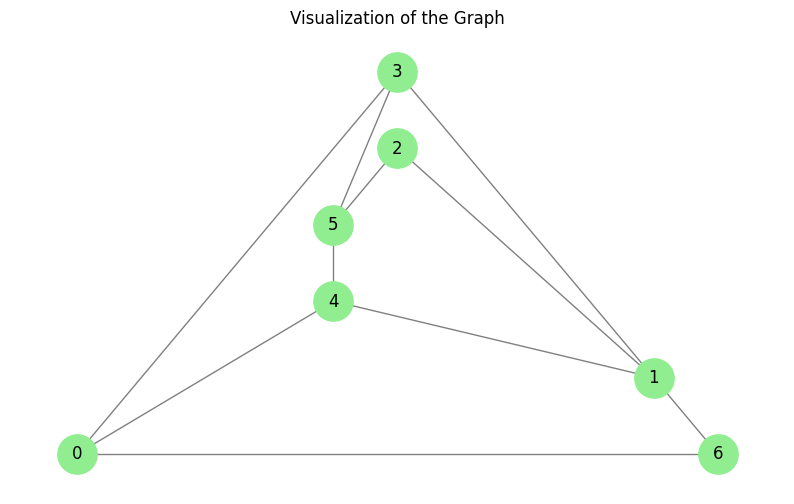

In [10]:
draw_graph(a)